In [3]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt



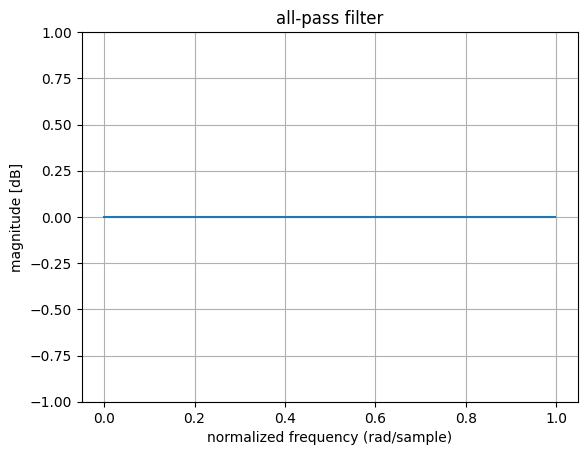

In [ ]:
#all pass filter
b = [1/3, 1]
a = [1, 1/3]

#frequency response
w, H = signal.freqz(b,a)



#plot magnitude
plt.plot(w/np.pi, 20*np.log10(np.abs(H)))
plt.ylim(-1,1)
plt.xlabel("normalized frequency (rad/sample)")
plt.ylabel("magnitude [dB]")
plt.title("all-pass filter")
plt.grid()
plt.show()



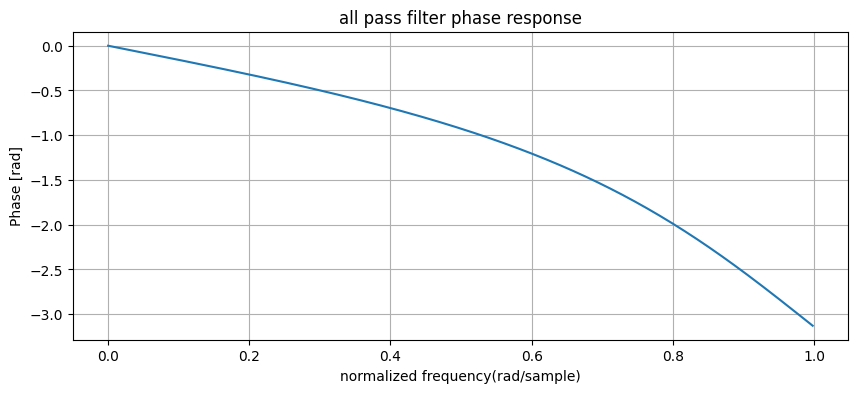

In [17]:
phase = np.unwrap(np.angle(H))

plt.figure(figsize=(10,4))
plt.plot(w/np.pi, phase)
plt.xlabel("normalized frequency(rad/sample)")
plt.ylabel("Phase [rad]")
plt.title("all pass filter phase response")
plt.grid()
plt.show()

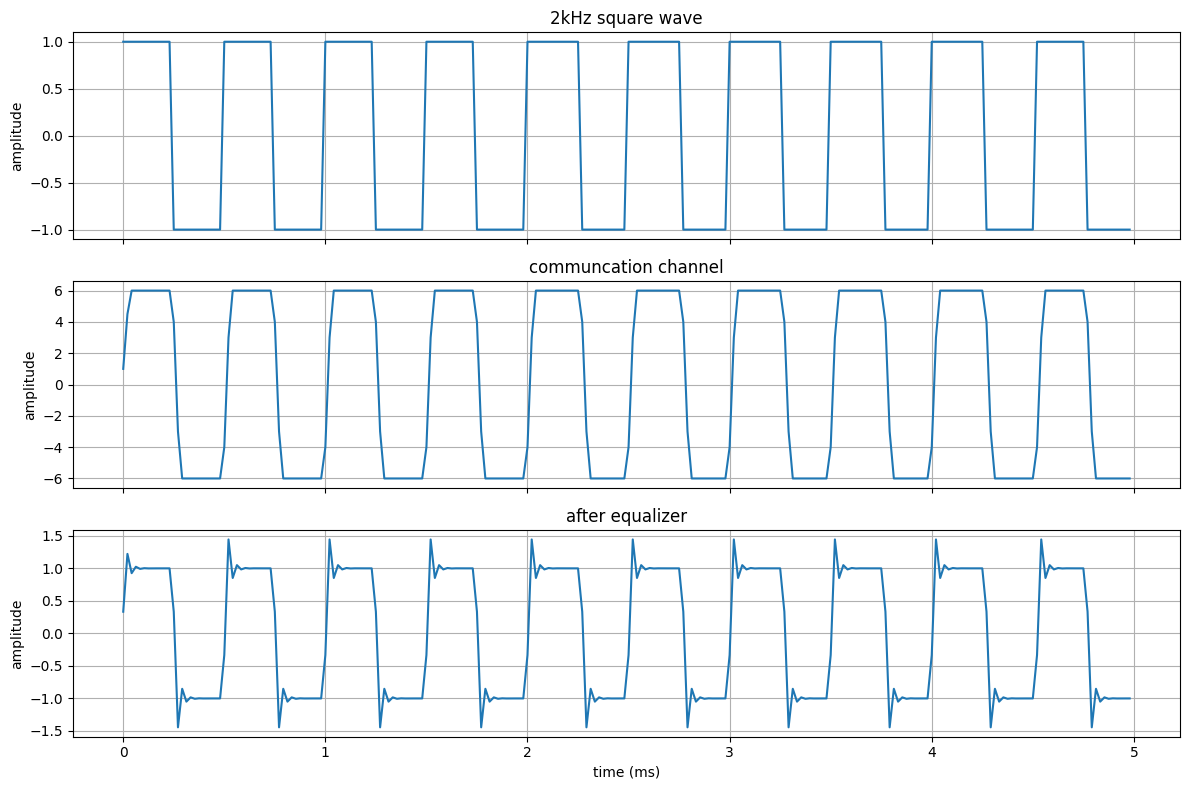

In [16]:
fs = 48000
f0 = 2000
duration = 0.005

#generate the time steps
t = np.arange(0,duration, 1/fs)
#generate the signal
x = signal.square(2 * np.pi*f0*t)

#communication channel system
#H(Z)= 1 + 3.5Z^-1 + 1.5Z^-2

b_channel = [1,3.5,1.5]
a_channel = [1]

#equalizer
#Heq_(Z) = 1/(3(1+0.5z^1)(1+(1/3)z^-1))
b_eq = [1]
a_eq = 3 * np.convolve([1,0.5], [1,1/3])

#pass the signal in both systems
y = signal.lfilter(b_channel, a_channel,x)
y_eq = signal.lfilter(b_eq, a_eq,y)

fig, axes = plt.subplots(3,1, figsize=(12,8), sharex=True)

axes[0].plot(t *1000, x)
axes[0].set_title("2kHz square wave")

axes[1].plot(t*1000, y)
axes[1].set_title("communcation channel")

axes[2].plot(t*1000, y_eq)
axes[2].set_title("after equalizer")

for ax in axes:
    ax.set_ylabel("amplitude")
    ax.grid(True)

axes[-1].set_xlabel("time (ms)")
plt.tight_layout()
plt.show()

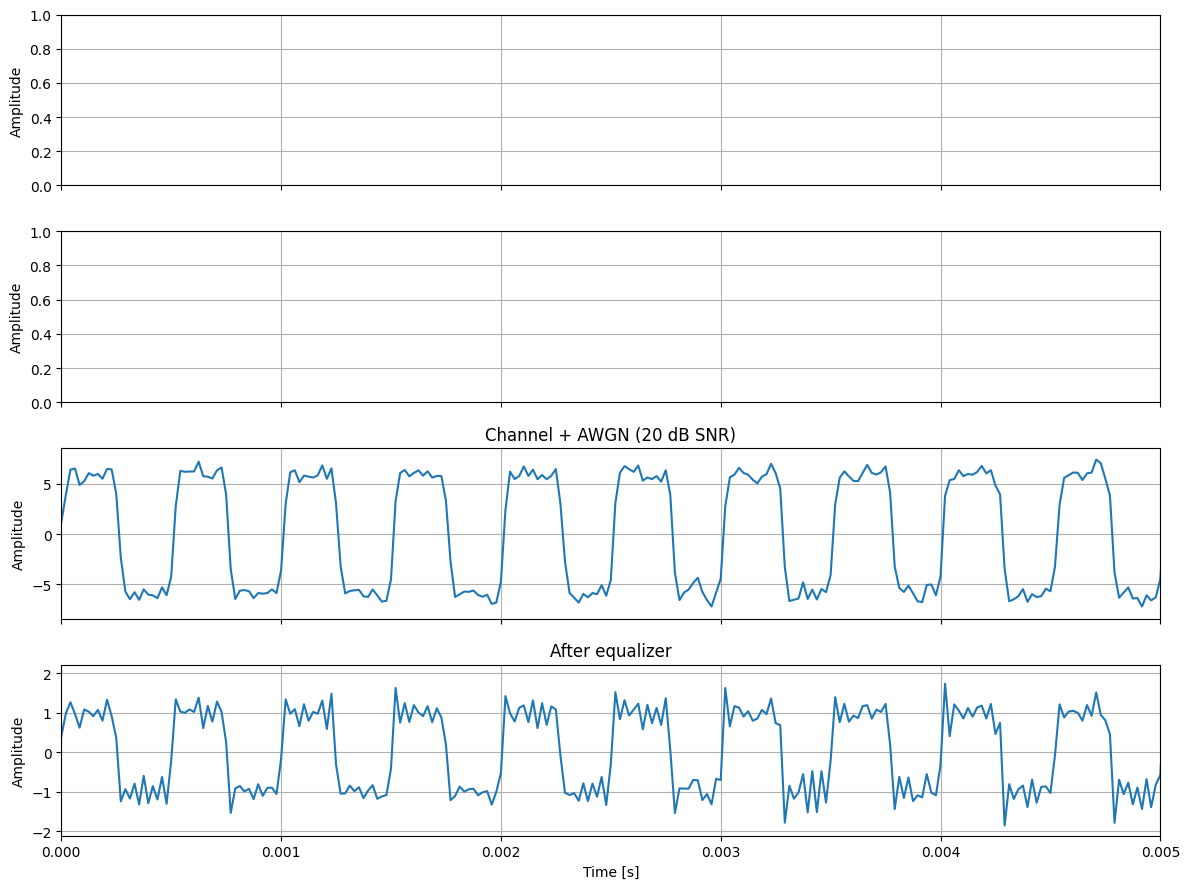

In [ ]:
# Original test signal: 2 kHz square wave
fs = 48000
f = 2000
duration = 0.02

t = np.arange(0, duration, 1/fs)
x = signal.square(2 * np.pi * f * t)

# Communication channel coefficients
# REPLACE these with your actual H(z) coefficients
b_channel = [1,3.5,1.5]
a_channel = [1]

# Pass the square wave through the channel
channel_output = signal.lfilter(
    b_channel, a_channel, x
)

# Desired signal-to-noise ratio
SNR_dB = 20

# Reproducible random noise
rng = np.random.default_rng(42)

# Calculate channel-output signal power
signal_power = np.mean(channel_output**2)

# Calculate required noise power
noise_power = signal_power / (10**(SNR_dB / 10))

# Generate white Gaussian noise
noise = rng.normal(
    loc=0,
    scale=np.sqrt(noise_power),
    size=len(channel_output)
)

# Add noise AFTER the channel
noisy_signal = channel_output + noise

# Apply your existing equalizer
equalized_signal = signal.lfilter(
    b_eq, a_eq, noisy_signal
)

t = np.arange(len(x)) / fs
# fig, ax = plt.subplots(
#     4, 1,
#     figsize=(12, 9),
#     sharex=True
# )

fig, ax = plt.subplots(
    2, 1,
    figsize=(12, 9),
    sharex=True
)

# ax[0].plot(t, x)
# ax[0].set_title("Original test signal")

# ax[1].plot(t, channel_output)
# ax[1].set_title("After communication channel")

ax[0].plot(t, noisy_signal)
ax[0].set_title(f"Channel + AWGN ({SNR_dB} dB SNR)")

ax[1].plot(t, equalized_signal)
ax[1].set_title("After equalizer")

for a in ax:
    a.grid(True)
    a.set_ylabel("Amplitude")

# Display the first 5 milliseconds
ax[0].set_xlim(0, 0.005)
ax[0].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()
